<a href="https://colab.research.google.com/github/shubham0328-pack/Titanic-Advanced-EDA/blob/main/advancededa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [4]:
df = pd.read_csv("Titanic-Dataset.csv")

print("First 5 rows:")
print(df.head())

print("\nMissing Values:")
print(df.isnull().sum())

First 5 rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

In [8]:

df['Age'].fillna(df['Age'].mean(), inplace=True)


/tmp/ipykernel_5457/1683867316.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [12]:

df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

/tmp/ipykernel_5457/3114099241.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)


In [14]:
print(df.columns)

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Embarked'],
      dtype='object')


In [15]:
df.drop(columns=['Cabin'], inplace=True, errors='ignore')

In [16]:
if 'Cabin' in df.columns:
    df.drop(columns=['Cabin'], inplace=True)

In [17]:
print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


Missing Values After Cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [18]:
bins = [0, 12, 20, 40, 60, 100]
labels = ['Child', 'Teen', 'Adult', 'Mid-age', 'Senior']
df['AgeGroup'] = pd.cut(df['Age'], bins=bins, labels=labels)

In [19]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [20]:
age_survival = df.groupby('AgeGroup')['Survived'].mean()
print("\nSurvival Rate by Age Group:\n", age_survival)


Survival Rate by Age Group:
 AgeGroup
Child      0.579710
Teen       0.381818
Adult      0.364769
Mid-age    0.390625
Senior     0.227273
Name: Survived, dtype: float64


/tmp/ipykernel_5457/2935568252.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_survival = df.groupby('AgeGroup')['Survived'].mean()


In [21]:
embark_survival = df.groupby('Embarked')['Survived'].mean()
print("\nSurvival Rate by Embarkation Port:\n", embark_survival)


Survival Rate by Embarkation Port:
 Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64


In [22]:
family_survival = df.groupby('FamilySize')['Survived'].mean()
print("\nSurvival Rate by Family Size:\n", family_survival)


Survival Rate by Family Size:
 FamilySize
1     0.303538
2     0.552795
3     0.578431
4     0.724138
5     0.200000
6     0.136364
7     0.333333
8     0.000000
11    0.000000
Name: Survived, dtype: float64


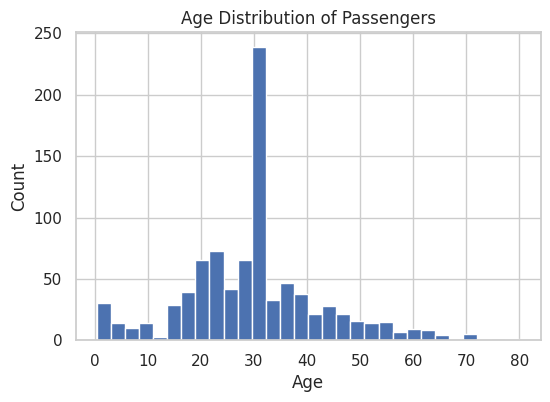

In [23]:
plt.figure(figsize=(6,4))
plt.hist(df['Age'], bins=30)
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

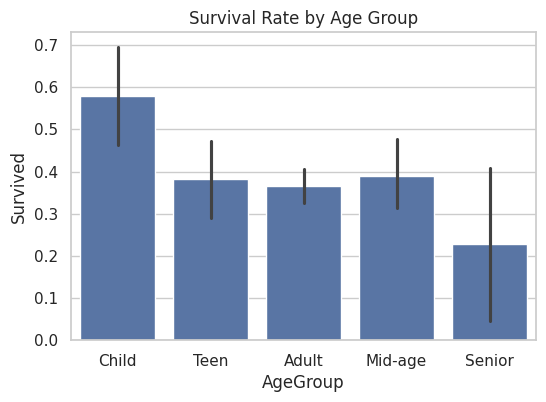

In [24]:
plt.figure(figsize=(6,4))
sns.barplot(x='AgeGroup', y='Survived', data=df)
plt.title("Survival Rate by Age Group")
plt.show()


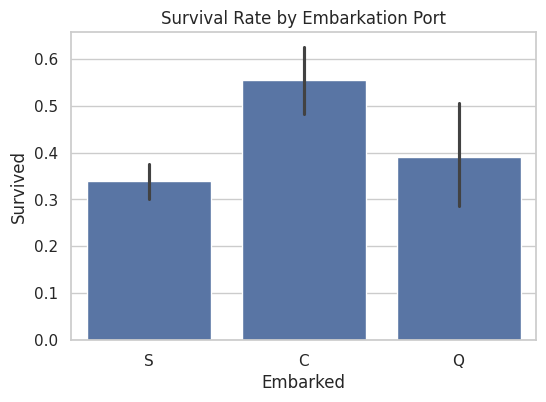

In [25]:
plt.figure(figsize=(6,4))
sns.barplot(x='Embarked', y='Survived', data=df)
plt.title("Survival Rate by Embarkation Port")
plt.show()

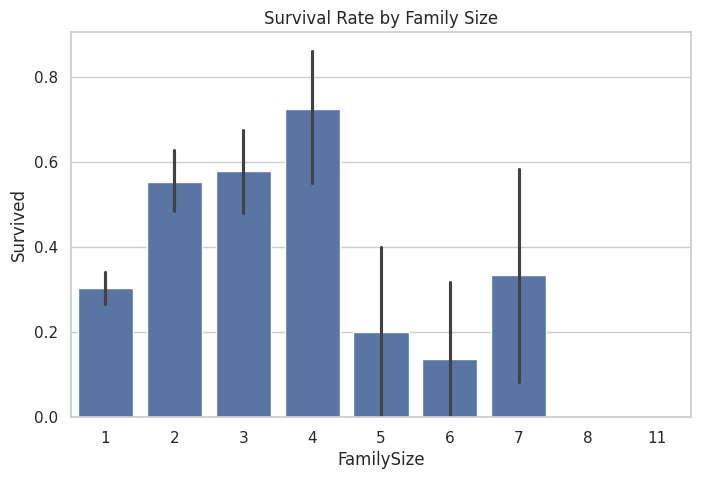

In [26]:
plt.figure(figsize=(8,5))
sns.barplot(x='FamilySize', y='Survived', data=df)
plt.title("Survival Rate by Family Size")
plt.show()


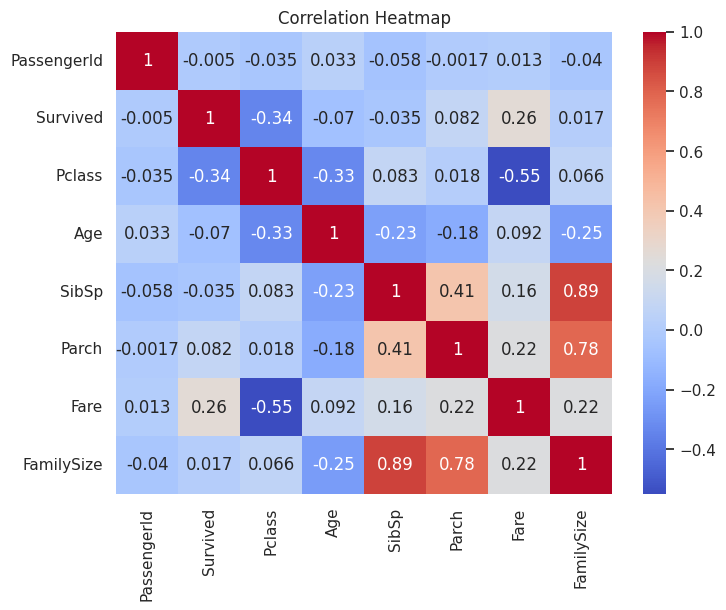

In [27]:
plt.figure(figsize=(8,6))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()